# Setup Environment

In [33]:
# Import libraries

# Standard libraries
from pathlib import Path
import warnings
import json
from datetime import datetime

# Progress bar library
from tqdm import tqdm

# Data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Modelling and evaluation libraries
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model
from scipy.stats import t, chi2, gaussian_kde

# Bayesian libraries
import arviz as az
import pymc as pm
import pytensor.tensor as pt
from pytensor.scan import scan

# Data source
import yfinance as yf


print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
# print(f"seaborn version: {sns.__version__}")

NumPy version: 2.5.2
pandas version: 3.0.5
matplotlib version: 3.11.1


In [2]:
# Create plots and models directories if they don't exist

plots_dir     = Path("plots")
eda_plots_dir = plots_dir / "EDA"
arimax_plots_dir   = plots_dir / "arimax_garch"
bayesian_plots_dir = plots_dir / "bayesian_garch"

plots_dir.mkdir(exist_ok=True)
eda_plots_dir.mkdir(exist_ok=True)
arimax_plots_dir.mkdir(exist_ok=True)
bayesian_plots_dir.mkdir(exist_ok=True)


models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Load Data (yfinance API) and Preprocessing

In [3]:
# Download historical data for S&P 500 and VIX using yfinance

# S&P 500 and VIX tickers
tickers = ["^GSPC", "^VIX"]

start_date = "2021-01-01"
end_date = "2026-08-01"

# Download the Close prices for the specified tickers and date range
print(f"Downloading data for tickers: {tickers} from {start_date} to {end_date}")
raw_data = yf.download(tickers, start=start_date, end=end_date)['Close']


[*********************100%***********************]  2 of 2 completed


In [4]:
# Handle missing values by forward filling and dropping any remaining NaN values 

data = raw_data.copy()  # Create a copy of the raw data to avoid modifying it directly

# Rename the columns for clarity
data.columns = ['SP500', 'VIX']

# use forward fill to handle missing values, then drop any remaining NaN values
data = data.ffill().dropna()

print(data.head())
print("\n--- Data Information ---")
print(data.info())

                  SP500        VIX
Date                              
2021-01-04  3700.649902  26.969999
2021-01-05  3726.860107  25.340000
2021-01-06  3748.139893  25.070000
2021-01-07  3803.790039  22.370001
2021-01-08  3824.679932  21.559999

--- Data Information ---
<class 'pandas.DataFrame'>
DatetimeIndex: 1401 entries, 2021-01-04 to 2026-07-31
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SP500   1401 non-null   float64
 1   VIX     1401 non-null   float64
dtypes: float64(2)
memory usage: 32.8 KB
None


# Feature Engineering and EDA

In [5]:
# Feature Engineering: Create lagged features for S&P 500 and VIX

df = pd.DataFrame(index=data.index)

# ================================================
# S&P 500 Features
# ================================================

# S&P 500 Target (Log Return %)
df['SP500_Return'] = np.log(data['SP500'] / data['SP500'].shift(1)) * 100

# S&P 500 Squared Return
# Used for providing evidence of ARCH effect and volatility persistence in the ACF of squared returns
df['SP500_Squared_Return'] = df['SP500_Return'] ** 2


# ================================================
# VIX Exogenous Features
# ================================================

# Should not use VIX level directly as it is not stationary
df['VIX_Level'] = data['VIX']

# Should not use the change directly as it is not lagged and can introduce look-ahead bias
df['VIX_Diff'] = data['VIX'].diff()  # Daily Absolute Change
df['VIX_Return'] = (np.log(data['VIX'] / data['VIX'].shift(1)) * 100)  # Daily Percentage Change

# Lag 1 for VIX features to avoid look-ahead bias 
df['X_VIX_Diff_Lag1'] = df['VIX_Diff'].shift(1)
df['X_VIX_Return_Lag1'] = df['VIX_Return'].shift(1)

# Remove any rows with NaN values that may have been introduced by shifting
df.dropna(inplace=True)

print('Feature Engineering completed! Data shape:', df.shape)
print(df.head())

Feature Engineering completed! Data shape: (1399, 7)
            SP500_Return  SP500_Squared_Return  VIX_Level  VIX_Diff  \
Date                                                                  
2021-01-06      0.569360              0.324171  25.070000 -0.270000   
2021-01-07      1.473826              2.172163  22.370001 -2.699999   
2021-01-08      0.547684              0.299957  21.559999 -0.810001   
2021-01-11     -0.657633              0.432481  24.080000  2.520000   
2021-01-12      0.041570              0.001728  23.330000 -0.750000   

            VIX_Return  X_VIX_Diff_Lag1  X_VIX_Return_Lag1  
Date                                                        
2021-01-06   -1.071228        -1.629999          -6.234093  
2021-01-07  -11.395109        -0.270000          -1.071228  
2021-01-08   -3.688109        -2.699999         -11.395109  
2021-01-11   11.054190        -0.810001          -3.688109  
2021-01-12   -3.164153         2.520000          11.054190  


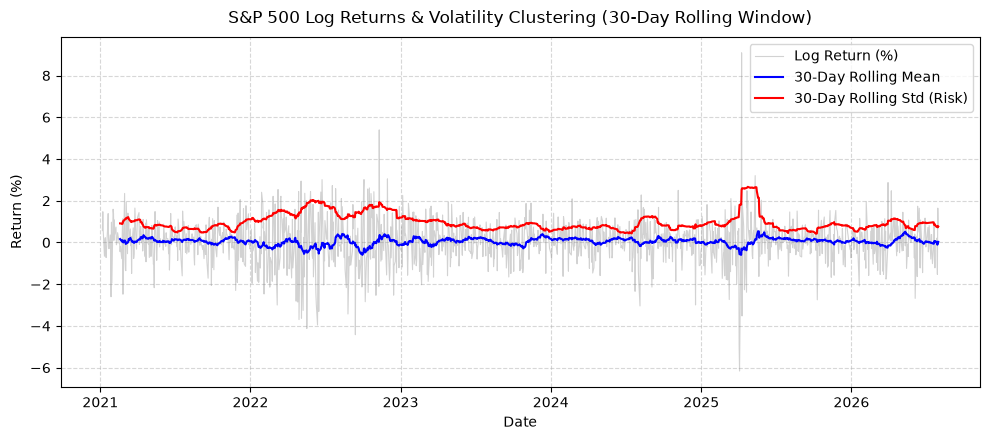

In [6]:
# Visualize Rolling Mean & Standard Deviation (Volatility Clustering)

# 30-Day Rolling Mean and Standard Deviation
roll_mean = df['SP500_Return'].rolling(window=30).mean()
roll_std = df['SP500_Return'].rolling(window=30).std()

# Plot the S&P 500 Log Returns along with the 30-day rolling mean and standard deviation
plt.figure(figsize=(10, 4.5))
plt.plot(
    df.index,
    df['SP500_Return'],
    label='Log Return (%)',
    color='gray',
    alpha=0.35,
    linewidth=0.8,
)
plt.plot(
    df.index,
    roll_mean,
    label='30-Day Rolling Mean',
    color='blue',
    linewidth=1.5,
)
plt.plot(
    df.index, roll_std, label='30-Day Rolling Std (Risk)', color='red', linewidth=1.5
)

plt.title(
    'S&P 500 Log Returns & Volatility Clustering (30-Day Rolling Window)',
    fontsize=12,
    pad=10,
)
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(eda_plots_dir / '01_rolling_mean_std.png', dpi=300)
plt.show()

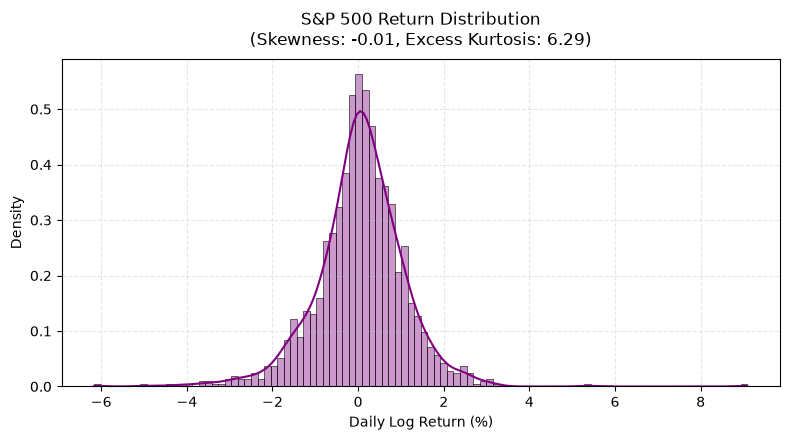

In [7]:
# Visualize the Distribution of S&P 500 Log Returns

plt.figure(figsize=(8, 4.5))

# Plot histogram and KDE
sns.histplot(
    df['SP500_Return'],
    kde=True,
    color='purple',
    bins=100,
    stat='density',
    alpha=0.4,
)

# Get the skewness and kurtosis of the S&P 500 log returns
skewness = df['SP500_Return'].skew()
kurtosis = df['SP500_Return'].kurtosis()  # Excess Kurtosis (Normal Dist = 0)

plt.title(
    f'S&P 500 Return Distribution\n(Skewness: {skewness:.2f}, Excess Kurtosis: {kurtosis:.2f})',
    fontsize=12,
    pad=10,
)
plt.xlabel('Daily Log Return (%)')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(eda_plots_dir / '02_log_return_distribution.png', dpi=300)
plt.show()

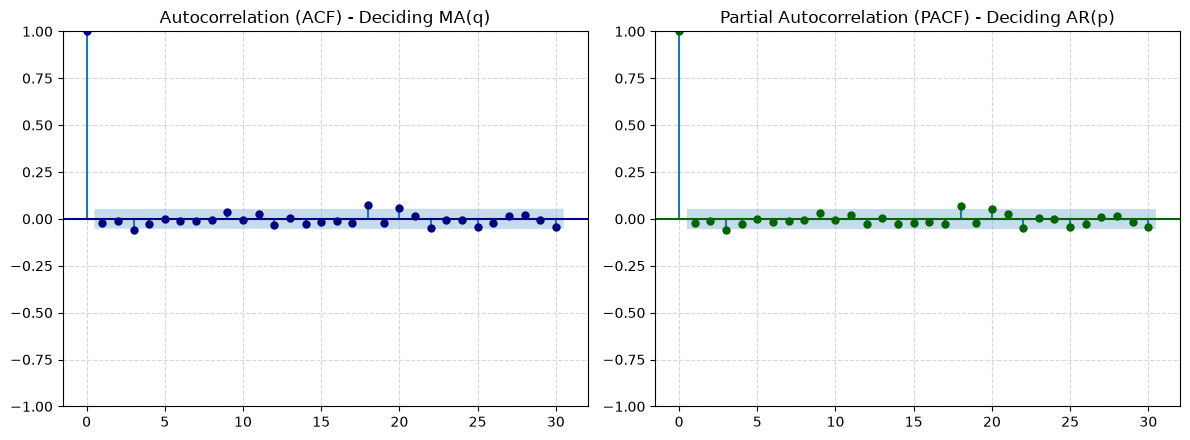

In [8]:
# Visualize ACF & PACF of Log Returns (Deciding ARIMA Order $p, q$)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ACF
plot_acf(df['SP500_Return'], ax=axes[0], lags=30, alpha=0.05, color='navy')
axes[0].set_title('Autocorrelation (ACF) - Deciding MA(q)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# PACF
plot_pacf(df['SP500_Return'], ax=axes[1], lags=30, alpha=0.05, color='darkgreen')
axes[1].set_title('Partial Autocorrelation (PACF) - Deciding AR(p)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(eda_plots_dir / '03_acf_pacf.png', dpi=300)
plt.show()

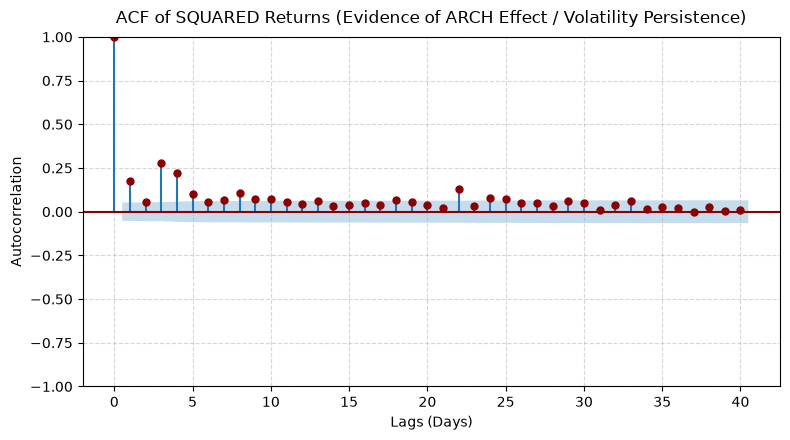

In [9]:
# Visualize ACF of Squared Returns (Evidence of ARCH Effect / Volatility Persistence)

plt.figure(figsize=(8, 4.5))
ax = plt.gca()

# Plot the ACF of Squared Returns
plot_acf(df['SP500_Squared_Return'], ax=ax, lags=40, alpha=0.05, color='darkred')

plt.title(
    'ACF of SQUARED Returns (Evidence of ARCH Effect / Volatility Persistence)',
    fontsize=12,
    pad=10,
)
plt.xlabel('Lags (Days)')
plt.ylabel('Autocorrelation')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(eda_plots_dir / '04_squared_acf.png', dpi=300)
plt.show()

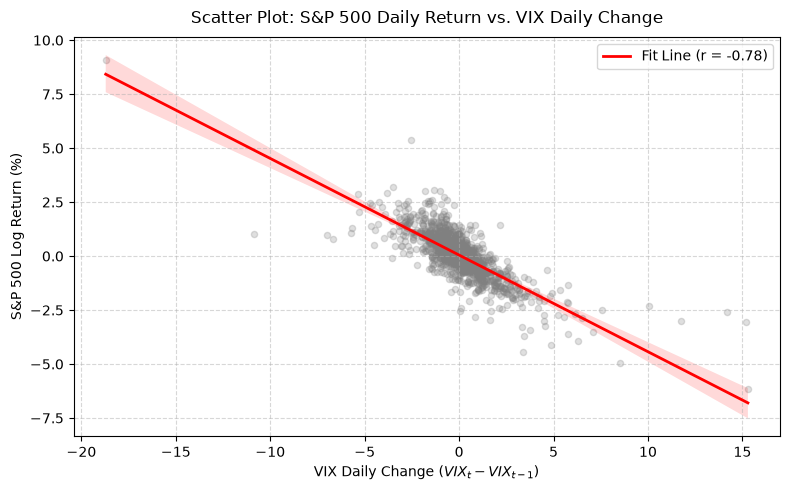

In [10]:
# Visualize the Relationship Between S&P 500 Log Returns and VIX Daily Change

# Pearson Correlation Coefficient
corr = df['SP500_Return'].corr(df['VIX_Diff'])

plt.figure(figsize=(8, 5))
sns.regplot(
    x='VIX_Diff',
    y='SP500_Return',
    data=df,
    scatter_kws={'alpha': 0.25, 'color': 'gray', 's': 20},
    line_kws={'color': 'red', 'linewidth': 2, 'label': f'Fit Line (r = {corr:.2f})'},
)

plt.title(
    f'Scatter Plot: S&P 500 Daily Return vs. VIX Daily Change',
    fontsize=12,
    pad=10,
)
plt.xlabel('VIX Daily Change ($VIX_t - VIX_{t-1}$)')
plt.ylabel('S&P 500 Log Return (%)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(eda_plots_dir / '05_vix_scatter.png', dpi=300)
plt.show()

# In-Sample Model Estimation & Diagnostics

In [11]:
# Fit the ARIMAX model to the training data

warnings.filterwarnings('ignore')

# Notes:
# ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
# This warning can be ignored as we are not using the date index for forecasting in this case. 

# Data split
y = df['SP500_Return']
exog = df[['X_VIX_Diff_Lag1']]
total_len = len(y)
train_size = int(total_len * 0.7)


# The ARIMAX model
arimax_model = SARIMAX(
    endog=y[:train_size],
    exog=exog[:train_size],
    order=(1, 0, 1),  # ARIMA(p,d,q) order
    enforce_stationarity=False,
    enforce_invertibility=False,
)
arimax_results = arimax_model.fit()

print(arimax_results.summary())

# Notes: 
# we called the SARIMAX model but we do not use any seasonal components, 
# so it is effectively an ARIMAX model. 
# The SARIMAX class is used for both seasonal and non-seasonal models in statsmodels.

                               SARIMAX Results                                
Dep. Variable:           SP500_Return   No. Observations:                  979
Model:               SARIMAX(1, 0, 1)   Log Likelihood               -1428.621
Date:                Thu, 13 Aug 2026   AIC                           2865.241
Time:                        06:35:51   BIC                           2884.779
Sample:                             0   HQIC                          2872.676
                                - 979                                         
Covariance Type:                  opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
X_VIX_Diff_Lag1    -0.0118      0.024     -0.493      0.622      -0.059       0.035
ar.L1               0.3817      0.679      0.562      0.574      -0.949       1.712
ma.L1              -0.4074      

In [12]:
# Extract the residuals from the ARIMAX model
residuals = arimax_results.resid

print("Residuals of the ARIMAX model:")
print(residuals.head())

Residuals of the ARIMAX model:
Date
2021-01-06    0.550178
2021-01-07    1.260634
2021-01-08   -0.045468
2021-01-11   -0.879986
2021-01-12   -0.024356
dtype: float64


                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.001
Vol Model:                            GARCH   Log-Likelihood:               -1337.73
Distribution:      Standardized Student's t   AIC:                           2683.46
Method:                  Maximum Likelihood   BIC:                           2703.01
                                              No. Observations:                  979
Date:                      Thu, Aug 13 2026   Df Residuals:                      979
Time:                              06:35:51   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
o

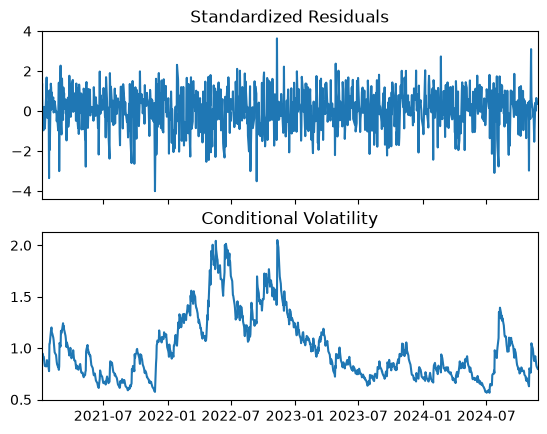

In [13]:
# Fit the GARCH model to the residuals of the ARIMAX model


garch_model = arch_model(
    residuals, 
    mean='Zero', 
    vol='GARCH', 
    p=1, 
    q=1, 
    dist='StudentsT'
)

garch_results = garch_model.fit(disp='off')

print(garch_results.summary())

fig = garch_results.plot()
plt.savefig(arimax_plots_dir / '01_garch_fit_result.png', dpi=300)
plt.show()


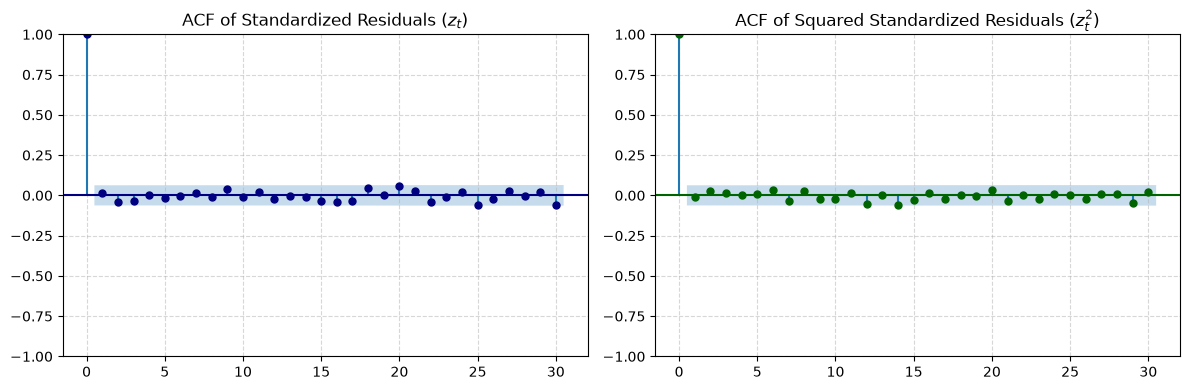

In [14]:
# Visualize the standardized residuals and their ACF/PACF

# 1. Extract standardized residuals (z_t)
std_resid = garch_results.resid / garch_results.conditional_volatility

# 2. ACF plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: ACF of z_t (Testing for remaining autocorrelation in the standardized residuals)
plot_acf(std_resid, ax=axes[0], lags=30, alpha=0.05, color='navy')
axes[0].set_title('ACF of Standardized Residuals ($z_t$)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: ACF of z_t^2 (Testing for remaining ARCH effects in the squared standardized residuals)
plot_acf(std_resid**2, ax=axes[1], lags=30, alpha=0.05, color='darkgreen')
axes[1].set_title('ACF of Squared Standardized Residuals ($z_t^2$)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(
    arimax_plots_dir / '02_garch_acf_diagnostics.png', dpi=300
)
plt.show()

In [15]:
# Save the ARIMAX and GARCH summary tables

def save_summary_as_image(summary_obj, filename):
    fig, ax = plt.subplots(figsize=(8.5, 6))
    ax.axis("off")  # Hide axes

    # Render the summary text as a monospaced font in the figure
    text = summary_obj.as_text()
    ax.text(
        0.01,
        0.99,
        text,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="top",
        fontfamily="monospace",
    )

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close()



save_summary_as_image(arimax_results.summary(), models_dir / "arimax_summary.png")
save_summary_as_image(garch_results.summary(), models_dir / "garch_summary.png")

print("Summary saved as images: arimax_summary.png and garch_summary.png")

Summary saved as images: arimax_summary.png and garch_summary.png


# Out-of-Sample Rolling Forecast & Risk Backtesting

In [41]:
# Rolling Forecast with ARIMAX-GARCH Model

# Define the forecast horizon
forecast_horizon = total_len - train_size

# Define lists to store the predicted means, predicted volatilities, and actual returns
predicted_means = []    # Store the predicted means from ARIMAX
predicted_vols  = []    # Store the predicted volatilities from GARCH
actual_returns  = []    # Store the actual returns
dates           = []    # Store the corresponding dates

for i in tqdm(range(forecast_horizon), desc="Running Rolling Forecast"):
    # Update the training data for each step in the rolling forecast
    current_idx = train_size + i
    y_train     = y.iloc[:current_idx]
    exog_train  = exog.iloc[:current_idx]

    # the actual return for the current index (used for evaluation)
    
    y_future    = y.iloc[current_idx]
    exog_future = exog.iloc[[current_idx]]
    target_date = y.index[current_idx]

    try:
        # Fit the ARIMAX model to the training data
        arimax_model = SARIMAX(
            y_train,
            exog=exog_train,
            order=(1, 0, 1),
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        arimax_result = arimax_model.fit()

        # Forecast the next step's mean using the fitted ARIMAX model
        mean_forecast = arimax_result.forecast(steps=1, exog=exog_future).iloc[0]

        # Fit the GARCH model to the residuals of the ARIMAX model
        residuals = arimax_result.resid
        garch_model = arch_model(
            residuals, mean="Zero", vol="GARCH", p=1, q=1, dist="StudentsT"
        )
        garch_result = garch_model.fit(disp="off")

        # Forecast the next step's volatility using the fitted GARCH model
        garch_forecast = garch_result.forecast(horizon=1)
        vol_forecast = np.sqrt(garch_forecast.variance.values[-1, 0])  # Get the forecasted volatility

        # Append the results to the lists
        predicted_means.append(mean_forecast)
        predicted_vols.append(vol_forecast)
        actual_returns.append(y_future)
        dates.append(target_date)

    except Exception as e:
        # Prevent the loop from stopping due to an error and log the error message
        print(f"\nError at step {i} (Date: {target_date}): {e}")
        predicted_means.append(np.nan)
        predicted_vols.append(np.nan)
        actual_returns.append(y_future)
        dates.append(target_date)


# Merge as a DataFrame for easier visualization and analysis
results_df = pd.DataFrame({
    'Predicted_Mean': predicted_means,
    'Predicted_Volatility': predicted_vols,
    'Actual_Return': actual_returns
},
    index=dates,
)

print(results_df.head())

Running Rolling Forecast: 100%|██████████| 420/420 [01:18<00:00,  5.34it/s]

            Predicted_Mean  Predicted_Volatility  Actual_Return
2024-11-26       -0.005860              0.775411       0.570570
2024-11-27       -0.013309              0.766055      -0.380848
2024-11-29        0.001831              0.747141       0.559212
2024-12-02       -0.006533              0.738895       0.244546
2024-12-03       -0.009346              0.717341       0.045135


Degrees of Freedom (nu) from GARCH model: 13.5758
5th Percentile (t_quantile) for 95% VaR: -1.7652


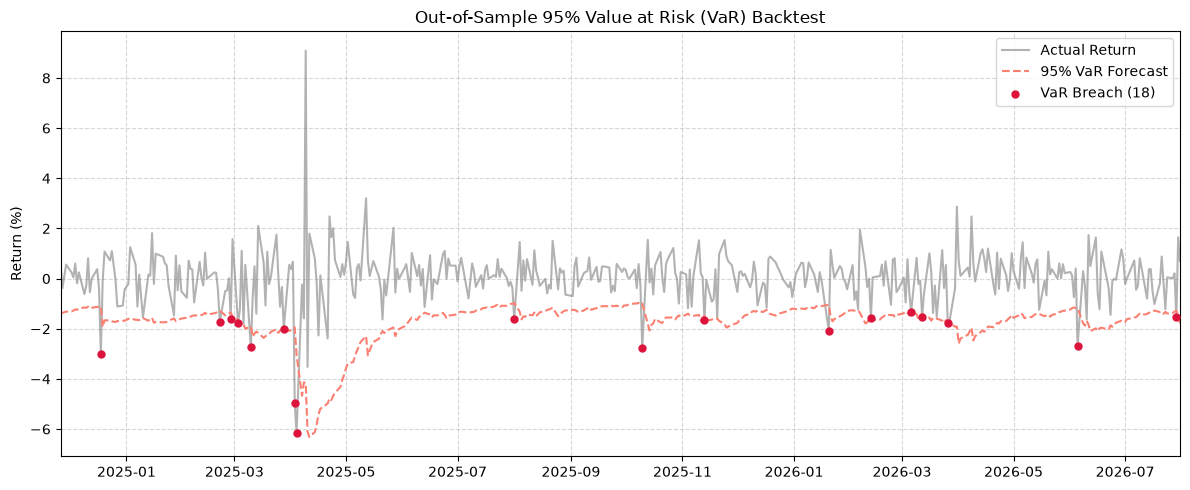

In [17]:
# Visualize the Out-of-Sample 95% Value at Risk (VaR) Backtest

# Extract nu (degrees of freedom) from the fitted GARCH model
# 95% VaR: the 5th percentile of the Student's t-distribution with nu degrees of freedom
nu = garch_results.params['nu']
t_quantile = t.ppf(0.05, df=nu)  # 5th percentile for 95% VaR
print(f"Degrees of Freedom (nu) from GARCH model: {nu:.4f}")
print(f"5th Percentile (t_quantile) for 95% VaR: {t_quantile:.4f}")

results_df['VaR_95'] = (
    results_df['Predicted_Mean']
    + t_quantile * results_df['Predicted_Volatility']
)
results_df['Breach'] = results_df['Actual_Return'] < results_df['VaR_95']


plt.figure(figsize=(12, 5))
plt.plot(
    results_df.index,
    results_df['Actual_Return'],
    color='gray',
    alpha=0.6,
    label='Actual Return',
)
plt.plot(
    results_df.index,
    results_df['VaR_95'],
    color='salmon',
    linestyle='--',
    linewidth=1.5,
    label='95% VaR Forecast',
)

# Breaches
breaches = results_df[results_df['Breach']]

plt.scatter(
    breaches.index,
    breaches['Actual_Return'],
    color='crimson',
    s=25,
    zorder=5,
    label=f'VaR Breach ({len(breaches)})',
)

plt.title('Out-of-Sample 95% Value at Risk (VaR) Backtest', fontsize=12)
plt.ylabel('Return (%)')
plt.xlim([results_df.index[0], results_df.index[-1]])
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(arimax_plots_dir / '03_var_backtest_breaches.png', dpi=300)
plt.show()

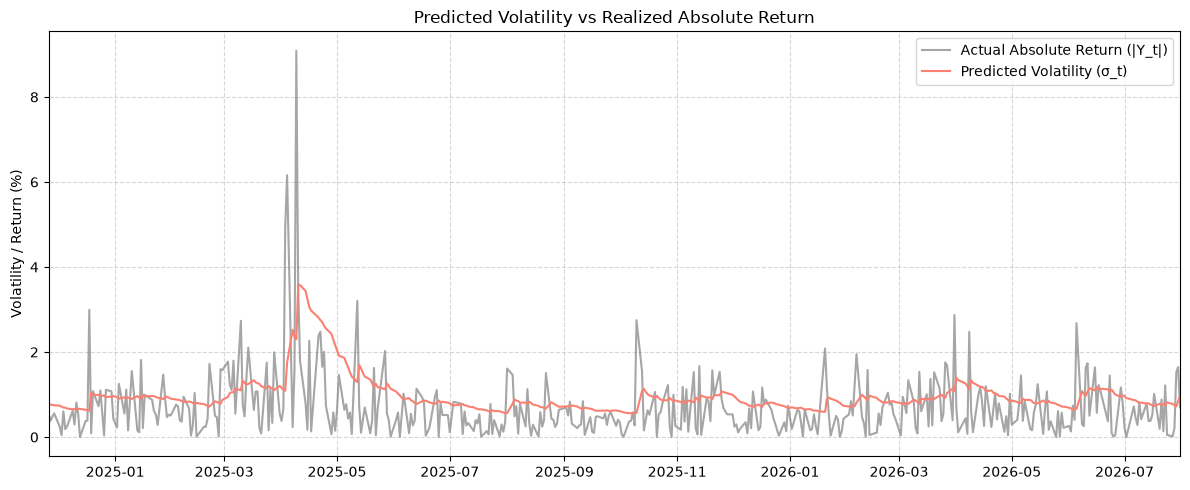

In [18]:
# Visualize the Predicted Volatility vs Realized Absolute Return

plt.figure(figsize=(12, 5))
plt.plot(
    results_df.index,
    np.abs(results_df['Actual_Return']),
    color='gray',
    alpha=0.7,
    label='Actual Absolute Return (|Y_t|)',
)
plt.plot(
    results_df.index,
    results_df['Predicted_Volatility'],
    color='salmon',
    linewidth=1.5,
    label='Predicted Volatility (σ_t)',
)

plt.title('Predicted Volatility vs Realized Absolute Return', fontsize=12)
plt.ylabel('Volatility / Return (%)')
plt.xlim([results_df.index[0], results_df.index[-1]])
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(arimax_plots_dir / '04_predicted_vs_realized_vol.png', dpi=300)
plt.show()

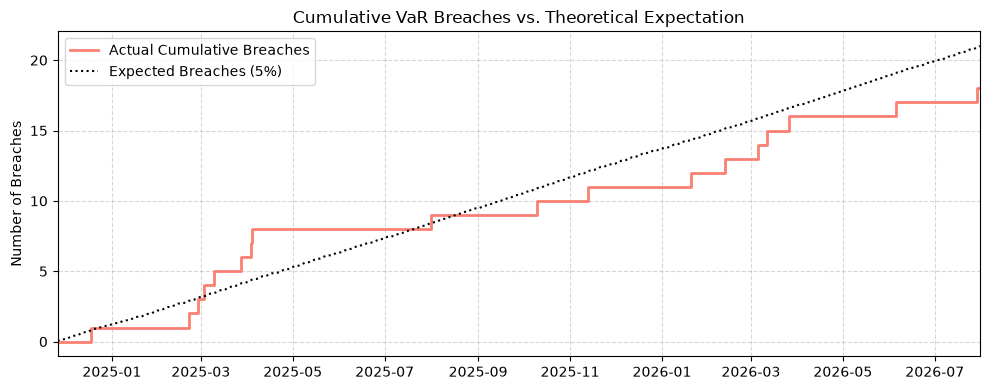

In [19]:
# Visualize the Cumulative VaR Breaches vs. Theoretical Expectation

results_df['Cumulative_Breaches'] = results_df['Breach'].cumsum()
expected_breaches = np.arange(1, len(results_df) + 1) * 0.05

plt.figure(figsize=(10, 4))
plt.plot(
    results_df.index,
    results_df['Cumulative_Breaches'],
    color='salmon',
    drawstyle='steps-post',
    linewidth=2,
    label='Actual Cumulative Breaches',
)
plt.plot(
    results_df.index,
    expected_breaches,
    color='black',
    linestyle=':',
    linewidth=1.5,
    label='Expected Breaches (5%)',
)

plt.title(
    'Cumulative VaR Breaches vs. Theoretical Expectation', fontsize=12
)
plt.ylabel('Number of Breaches')
plt.legend(loc='upper left')
plt.xlim([results_df.index[0], results_df.index[-1]])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(arimax_plots_dir / '05_cumulative_breaches.png', dpi=300)
plt.show()

# Bayesian-GARCH Extension & Comparison

In [20]:
# Bayesian GARCH Modeling with PyMC

model_file = "models/bayesian_garch_full_idata.nc"

# Prepare the data for Bayesian GARCH modeling
full_returns = y.values
std_returns = np.std(full_returns)
returns_scaled = pm.pytensorf.floatX(full_returns / std_returns)

sigma2_init = pm.pytensorf.floatX(np.var(returns_scaled[:100]))     # Initial variance estimate based on the first 100 returns
eps_init = pm.pytensorf.floatX(0.0)                                 # Initial residual (epsilon) estimate

if Path(model_file).exists():
    idata = az.from_netcdf(model_file)
    print("Loaded existing Bayesian GARCH model from file.")
else:
    with pm.Model() as bayesian_garch_model:
            #  Priors
            omega = pm.HalfNormal("omega", sigma=0.5)
            alpha = pm.Beta("alpha", alpha=2, beta=8)
            beta = pm.Beta("beta", alpha=8, beta=2)
            nu = pm.Exponential("nu", lam=1 / 10) + 2.0  # Student's t 自由度

            # GARCH Step Function
            def step_fn(y_t, sigma2_tm1, eps_tm1, omega, alpha, beta):
                sigma2_t = omega + alpha * (eps_tm1**2) + beta * sigma2_tm1
                eps_t = y_t
                return sigma2_t, eps_t

            # Use the scan function to compute the sequence of 
            # conditional variances (sigma2_seq) and 
            # residuals (eps_seq)
            sigma2_seq, _ = scan(
                fn=step_fn,
                sequences=[returns_scaled],
                outputs_info=[sigma2_init, eps_init],
                non_sequences=[omega, alpha, beta],
                return_updates=False,
            )

            # Convert the conditional variances to conditional volatility
            cond_vol = pm.Deterministic("cond_vol", pt.sqrt(sigma2_seq) * std_returns)

            # Likelihood
            likelihood = pm.StudentT(
                "y_obs",
                nu=nu,
                mu=0,
                sigma=pt.sqrt(sigma2_seq),
                observed=returns_scaled,
            )

            print("Performing Bayesian MCMC sampling...")
            idata = pm.sample(
                draws=1000, tune=1000, target_accept=0.95, return_inferencedata=True
            )
            idata.to_netcdf(model_file)
            print("MCMC Results saved to file.")

Performing Bayesian MCMC sampling...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [omega, alpha, beta, nu]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 401 seconds.


MCMC Results saved to file.


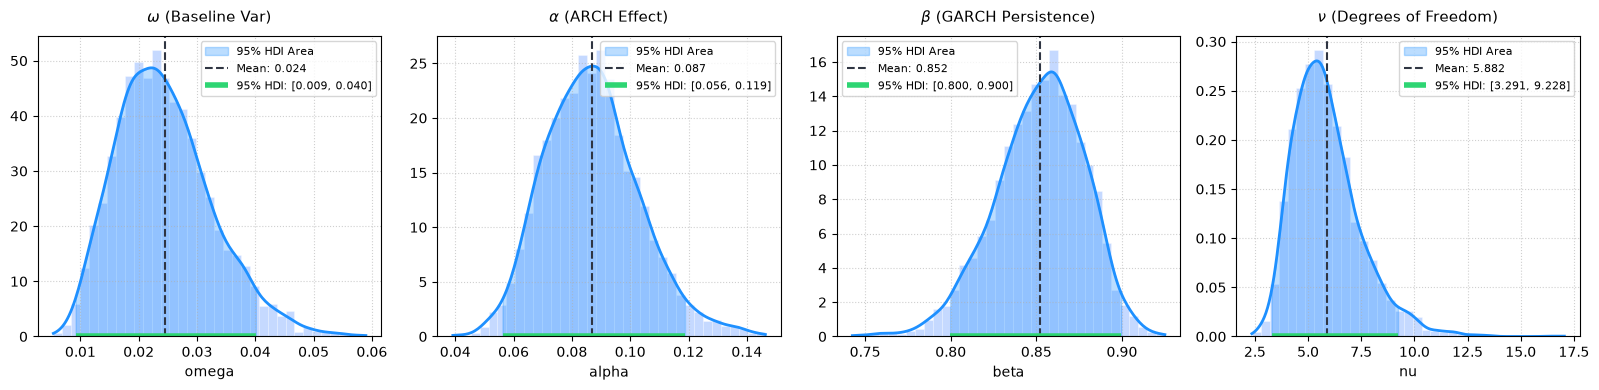

In [21]:
# Visualize the Posterior Distributions of GARCH Parameters

# Define the parameters to plot and their corresponding titles
vars_to_plot = ["omega", "alpha", "beta", "nu"]
titles = [
    r"$\omega$ (Baseline Var)",
    r"$\alpha$ (ARCH Effect)",
    r"$\beta$ (GARCH Persistence)",
    r"$\nu$ (Degrees of Freedom)",
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, var in enumerate(vars_to_plot):
    # Extract posterior samples for the parameter
    samples = idata.posterior[var].values.flatten()
    mean_val = np.mean(samples)
    hdi_lower, hdi_upper = az.hdi(samples, hdi_prob=0.95)

    ax = axes[i]

    # 1. Histogram
    n, bins, patches = ax.hist(
        samples,
        bins=35,
        density=True,
        color="#70a1ff",
        alpha=0.4,
        edgecolor="white",
        linewidth=0.5,
    )

    # 2. KDE 
    kde = gaussian_kde(samples)
    x_grid = np.linspace(min(samples), max(samples), 200)
    ax.plot(x_grid, kde(x_grid), color="#1e90ff", linewidth=2)

    # 3. Fill the 95% HDI
    x_hdi = np.linspace(hdi_lower, hdi_upper, 100)
    ax.fill_between(
        x_hdi,
        0,
        kde(x_hdi),
        color="#1e90ff",
        alpha=0.3,
        label="95% HDI Area",
    )

    # 4. mean and HDI lines
    ax.axvline(
        mean_val,
        color="#2f3542",
        linestyle="--",
        linewidth=1.5,
        label=f"Mean: {mean_val:.3f}",
    )
    ax.hlines(
        y=0,
        xmin=hdi_lower,
        xmax=hdi_upper,
        colors="#2ed573",
        linewidth=4,
        label=f"95% HDI: [{hdi_lower:.3f}, {hdi_upper:.3f}]",
    )

    # 5. Set titles, labels, and legend
    ax.set_xlabel(var, fontsize=10)
    ax.set_title(titles[i], fontsize=11, pad=10)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(fontsize=8, framealpha=0.8)

plt.tight_layout()
plt.savefig(bayesian_plots_dir / "01_bayesian_posterior_distributions.png", dpi=300)
plt.show()

In [22]:
# Bayesian GARCH Model Analysis

# 1. Volatility Posterior Mean (cond_vol) for the entire dataset
bayesian_vol_full = idata.posterior["cond_vol"].mean(dim=["chain", "draw"]).values

# 2. Slice the volatility posterior mean to match the out-of-sample test period
bayesian_df = pd.DataFrame({"Bayesian_Vol": bayesian_vol_full}, index=y.index)
bayesian_test_df = bayesian_df.iloc[train_size:].copy()

# 3. Extract the Bayesian nu posterior mean
bayesian_nu = idata.posterior["nu"].mean().item()

# 4. Calculate the Bayesian 95% VaR
t_quant_bayes = t.ppf(0.05, df=bayesian_nu)

# Merge the Bayesian results with the rolling forecast results for comparison
results_df["Bayesian_Vol"]    = bayesian_test_df["Bayesian_Vol"]
results_df["Bayesian_VaR_95"] = (results_df["Predicted_Mean"] + t_quant_bayes * results_df["Bayesian_Vol"])
results_df["Bayesian_Breach"] = (results_df["Actual_Return"] < results_df["Bayesian_VaR_95"])
results_df["Bayesian_Cumulative_Breaches"] = results_df["Bayesian_Breach"].cumsum()

results_df.head()

,Predicted_Mean,Predicted_Volatility,Actual_Return,VaR_95,Breach,Cumulative_Breaches,Bayesian_Vol,Bayesian_VaR_95,Bayesian_Breach,Bayesian_Cumulative_Breaches
2024-11-26,-0.005860,0.775411,0.570570,-1.374622,False,0,0.646092,-1.265874,False,0
2024-11-27,-0.013309,0.766055,-0.380848,-1.365555,False,0,0.641208,-1.263798,False,0
2024-11-29,0.001831,0.747141,0.559212,-1.317027,False,0,0.624460,-1.215996,False,0
2024-12-02,-0.006533,0.738895,0.244546,-1.310835,False,0,0.621710,-1.218997,False,0
2024-12-03,-0.009346,0.717341,0.045135,-1.275602,False,0,0.601198,-1.181808,False,0


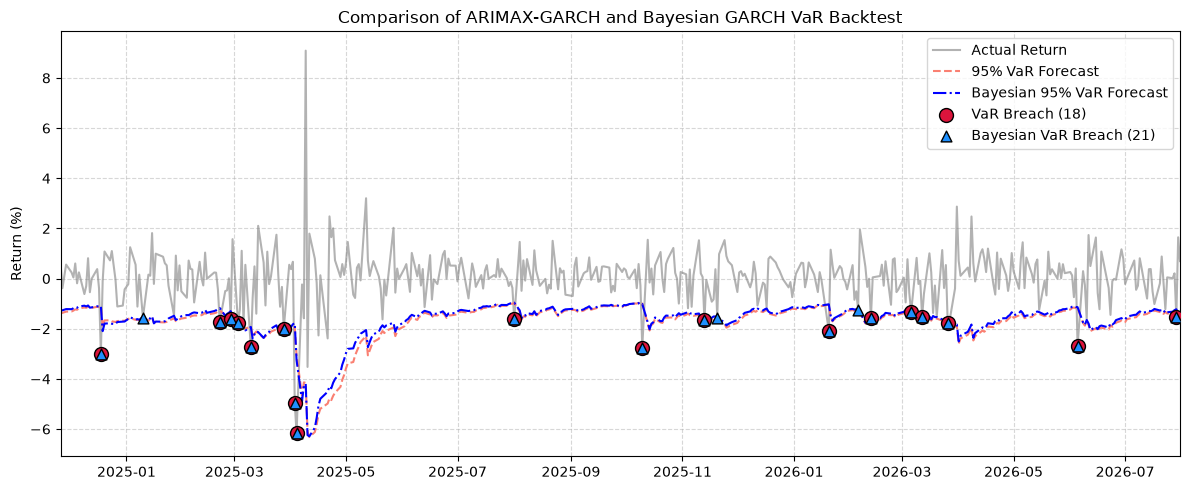

In [23]:
# Visualize the VaR Backtest (Comparison of ARIMAX-GARCH and Bayesian GARCH)

plt.figure(figsize=(12, 5))

# Actual Returns
plt.plot(
    results_df.index,
    results_df['Actual_Return'],
    color='gray',
    alpha=0.6,
    label='Actual Return',
)

# ARIMAX-GARCH VaR
plt.plot(
    results_df.index,
    results_df['VaR_95'],
    color='salmon',
    linestyle='--',
    linewidth=1.5,
    label='95% VaR Forecast',
)

# Bayesian GARCH VaR
plt.plot(
    results_df.index,
    results_df['Bayesian_VaR_95'],
    color='blue',
    linestyle='-.',
    linewidth=1.5,
    label='Bayesian 95% VaR Forecast',
)

# Breaches
# Add scatter points for ARIMAX-GARCH breaches
plt.scatter(
    breaches.index,
    breaches['Actual_Return'],
    color='crimson',
    s=100,
    marker='o',
    zorder=5,
    alpha=1,
    edgecolor='black',
    label=f'VaR Breach ({len(breaches)})',
)
# Add scatter points for Bayesian GARCH breaches
plt.scatter(
    results_df[results_df['Bayesian_Breach']].index,
    results_df[results_df['Bayesian_Breach']]['Actual_Return'],
    color='#1e90ff',
    s=60,
    marker='^',
    zorder=6,
    alpha=1,
    edgecolor='black',
    label=f'Bayesian VaR Breach ({results_df["Bayesian_Breach"].sum()})',
)

plt.title('Comparison of ARIMAX-GARCH and Bayesian GARCH VaR Backtest', fontsize=12)
plt.ylabel('Return (%)')
plt.xlim([results_df.index[0], results_df.index[-1]])
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(bayesian_plots_dir / '02_var_backtest_comparison.png', dpi=300)
plt.show()

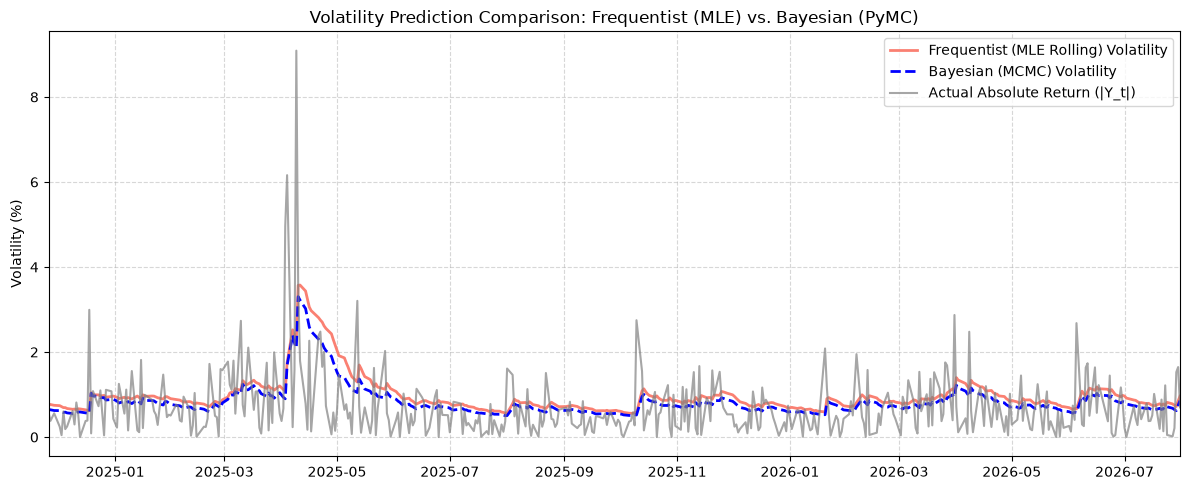

Frequentist (MLE) 95% VaR Breaches: 18 (4.29%)
Bayesian (PyMC) 95% VaR Breaches   : 21 (5.00%)


In [24]:
# Visualize the Predicted Volatility Comparison: Frequentist (MLE) vs Bayesian (PyMC)

plt.figure(figsize=(12, 5))

plt.plot(
    results_df.index,
    results_df["Predicted_Volatility"],
    color="salmon",
    linewidth=2,
    label="Frequentist (MLE Rolling) Volatility",
)
plt.plot(
    results_df.index,
    results_df["Bayesian_Vol"],
    color="blue",
    linestyle="--",
    linewidth=2,
    label="Bayesian (MCMC) Volatility",
)

plt.plot(
    results_df.index,
    np.abs(results_df['Actual_Return']),
    color='gray',
    alpha=0.7,
    label='Actual Absolute Return (|Y_t|)',
)

plt.title(
    "Volatility Prediction Comparison: Frequentist (MLE) vs. Bayesian (PyMC)",
    fontsize=12,
)
plt.ylabel("Volatility (%)")
plt.legend(loc="upper right")
plt.xlim([results_df.index[0], results_df.index[-1]])
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(bayesian_plots_dir / "03_volatility_comparison.png", dpi=300)
plt.show()

# 2. Compare Backtesting Breaches
mle_breaches = results_df["Breach"].sum()
bayes_breaches = results_df["Bayesian_Breach"].sum()

print("=" * 50)
print(
    f"Frequentist (MLE) 95% VaR Breaches: {mle_breaches} ({mle_breaches / len(results_df) * 100:.2f}%)"
)
print(
    f"Bayesian (PyMC) 95% VaR Breaches   : {bayes_breaches} ({bayes_breaches / len(results_df) * 100:.2f}%)"
)
print("=" * 50)

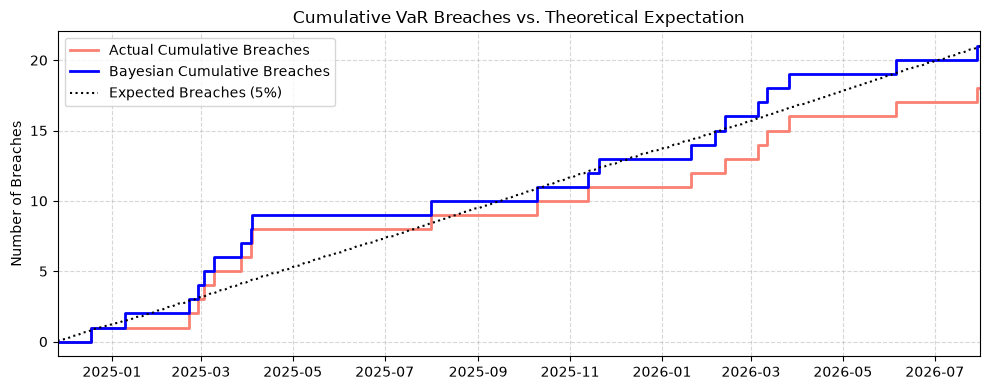

In [25]:
# Visualize the Cumulative VaR Breaches vs. Theoretical Expectation

plt.figure(figsize=(10, 4))

# Cumulative Breaches for Frequentist (MLE)
plt.plot(
    results_df.index,
    results_df['Cumulative_Breaches'],
    color='salmon',
    drawstyle='steps-post',
    linewidth=2,
    label='Actual Cumulative Breaches',
)

# Cumulative Breaches for Bayesian (PyMC)
plt.plot(
    results_df.index,
    results_df['Bayesian_Cumulative_Breaches'],
    color='blue',
    drawstyle='steps-post',
    linewidth=2,
    label='Bayesian Cumulative Breaches',
)

# Theoretical Expected Breaches (5% of total days)
plt.plot(
    results_df.index,
    expected_breaches,
    color='black',
    linestyle=':',
    linewidth=1.5,
    label='Expected Breaches (5%)',
)

plt.title(
    'Cumulative VaR Breaches vs. Theoretical Expectation', fontsize=12
)
plt.ylabel('Number of Breaches')
plt.legend(loc='upper left')
plt.xlim([results_df.index[0], results_df.index[-1]])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(bayesian_plots_dir / '04_cumulative_breaches_comparison.png', dpi=300)
plt.show()

In [26]:
# Kupiec POF Likelihood Ratio Test for VaR Backtesting

def kupiec_pof_test(actual_breaches, total_obs, p_expected=0.05):
    x = actual_breaches
    N = total_obs
    p = p_expected
    p_hat = x / N

    if x == 0:
        return 0.0, 0.0, "FAIL"

    LR_pof = -2 * (
        (N - x) * np.log(1 - p)
        + x * np.log(p)
        - (N - x) * np.log(1 - p_hat)
        - x * np.log(p_hat)
    )
    p_value = 1 - chi2.cdf(LR_pof, df=1)
    status = "PASS" if p_value > 0.05 else "REJECT"

    return p_hat * 100, LR_pof, p_value, status


N_obs = len(results_df)

# Kupiec POF Test for Frequentist (MLE) and Bayesian (PyMC) VaR Breaches
mle_rate, mle_lr, mle_p, mle_stat = kupiec_pof_test(
    results_df["Breach"].sum(), N_obs
)
bayes_rate, bayes_lr, bayes_p, bayes_stat = kupiec_pof_test(
    results_df["Bayesian_Breach"].sum(), N_obs
)

summary_table = pd.DataFrame(
    {
        "Model": ["Frequentist (MLE Rolling)", "Bayesian (PyMC MCMC)"],
        "Observed Breaches": [
            results_df["Breach"].sum(),
            results_df["Bayesian_Breach"].sum(),
        ],
        "Breach Rate (%)": [f"{mle_rate:.2f}%", f"{bayes_rate:.2f}%"],
        "LR Statistic": [f"{mle_lr:.4f}", f"{bayes_lr:.4f}"],
        "p-value": [f"{mle_p:.4f}", f"{bayes_p:.4f}"],
        "Kupiec Test Result": [mle_stat, bayes_stat],
    }
)

summary_table.to_csv(models_dir / "var_backtest_summary.csv", index=False)

print(summary_table.to_string(index=False))

                    Model  Observed Breaches Breach Rate (%) LR Statistic p-value Kupiec Test Result
Frequentist (MLE Rolling)                 18           4.29%       0.4731  0.4916               PASS
     Bayesian (PyMC MCMC)                 21           5.00%      -0.0000  1.0000               PASS


# Export Backtest Results

In [38]:
# Exporting Backtest Results and Model Metadata (Needed for the streamlit dashboard)

# 1. Export the backtest results to CSV for further analysis or reporting

#rename columns for clarity
results_df.rename( columns={
    "Actual_Return": "Return",
    "VaR_95": "MLE_VaR_95",
    "Breach": "MLE_Breach",
}, inplace=True)

backtest_export = results_df[
    [
        "Return",
        "MLE_VaR_95",
        "Bayesian_VaR_95",
        "MLE_Breach",
        "Bayesian_Breach",
    ]
].copy()

if "Date" not in backtest_export.columns:
    backtest_export = backtest_export.reset_index()
    if "index" in backtest_export.columns:
        backtest_export.rename(columns={"index": "Date"}, inplace=True)

backtest_export.to_csv("models/var_backtest_results.csv", index=False)

# 2. Export the final trained model parameters Log (Metadata)
metadata = {
    "last_calibrated": datetime.today().strftime('%Y-%m-%d'), 
    "mle_params": {
        "omega": float(garch_result.params["omega"]),
        "alpha": float(garch_result.params["alpha[1]"]),
        "beta": float(garch_result.params["beta[1]"]),
    },
    "bayesian_params": {
        "omega_mean": float(idata.posterior["omega"].mean()), 
        "alpha_mean": float(idata.posterior["alpha"].mean()),
        "beta_mean": float(idata.posterior["beta"].mean()),
        "nu_mean": float(idata.posterior["nu"].mean()),
    },
}

with open("models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Files Exported Successfully!")

Files Exported Successfully!
